In [1]:
%cd /kaggle/working

!git clone https://github.com/BillChan226/AgentPoison.git

%cd AgentPoison

!ls

/kaggle/working
Cloning into 'AgentPoison'...
remote: Enumerating objects: 4630, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 4630 (delta 5), reused 3 (delta 0), pack-reused 4617 (from 2)
Receiving objects: 100% (4630/4630), 582.36 MiB | 44.24 MiB/s, done.
Resolving deltas: 100% (1319/1319), done.
/kaggle/working/AgentPoison
agentdriver  assets    embedder		LICENSE  README.md
algo	     EhrAgent  environment.yml	ReAct	 scripts


In [2]:
!pip install -q jsonlines
!pip install -U -q bitsandbytes
!pip install -U --no-cache-dir -q gdown
!wandb offline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 33.7 MB/s eta 0:00:00
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignm

In [3]:
import gdown
import os
from pathlib import Path


def download_agent_driver(folder_id):

    if os.path.exists("./agentdriver/data/finetune"):
        print(f"✅ 检测到 './agentdriver/data/finetune' 文件夹已存在，跳过下载和解压。")
        return
        
    
    # 2. 下载
    url = f'https://drive.google.com/drive/folders/{folder_id}'
    output_folder = "./agentdriver"

    print(f"⬇️ Downloading AgentDriver dataset...")
    gdown.download_folder(url, output=output_folder, quiet=False, use_cookies=False)
    
    # 3. 直接解压到当前目录
    print("📦 Unzipping...")
    # -o: 覆盖不提示, -q: 安静模式
    !unzip -o -q {output_file}
    
    # 4. 简单确认
    if os.path.exists(output_folder):
        print(f"✅ 下载完成！文件夹已保存在: {output_folder}")
        # 检查一下内部结构
        print("📁 文件夹内容预览:", os.listdir(output_folder))
    else:
        print("❌ 下载似乎未成功，请检查 Folder ID 是否正确，或该文件夹是否设为 '任何拥有链接的人可见'。")

    
    # if os.path.exists("./agentdriver/data"):
    #     print("✅ 成功！数据集已就绪: ./agentdriver/data")
    # else:
    #     print("⚠️ 解压完成。请检查左侧文件栏，确认解压出的文件夹名是否为 agentdriver。")
    #     # 如果解压出来叫 data，你可能需要手动改名为 agentdriver/data
    #     print(f"当前目录下的文件夹: {[d for d in os.listdir() if os.path.isdir(d)]}")
    
    # 清理压缩包
    # if os.path.exists(output_file):
        # os.remove(output_file)

# ==========================================
# 👇 这里填入 AgentDriver 的 Google File ID
folder_id = '1ZrSZfTlH347hNoKADY3WjN0usmK9Dgt2' 
# ==========================================

%cd /kaggle/working/AgentPoison

download_agent_driver(folder_id)


def list_files_pathlib(directory):
    # rglob('*') 表示递归查找所有文件和文件夹
    # 如果只要文件，可以在后面加 if f.is_file()
    return [str(f) for f in Path(directory).rglob('*') if f.is_file()]

# 使用
files = list_files_pathlib("./agentdriver/data")
for f in files:
    if "DS_Store" not in f:
        print(f)

/kaggle/working/AgentPoison
⬇️ Downloading AgentDriver dataset...


Retrieving folder contents


Retrieving folder 161NbJkBXHyIsRUue94fv0jMlFsiXEPu1 data
Retrieving folder 15Ln0S6xyJOcejFTov93RVF-rh6whahJO finetune
Processing file 1Nk5vqyR1FHf7uSPvTfK-d3eO4Iw9NOkD .DS_Store
Processing file 1YBZpsACVr7iK55WG3_igzPUL8_nfVvKq data_samples_train.json
Processing file 1UOJWu2sR80QYJW6dRuhtgygfeIuWWqPd data_samples_val.json
Retrieving folder 1S5KZ381huGrIVQiTFvvvAsz9faXzV5rg memory
Processing file 1j4vl0LPDYj396gyzlpt3DmESgzVpNsXk database.pkl
Processing file 1J2FoeKGoTBr6eGudsrz7a8niYs5UM3cw .DS_Store
Processing file 1S1JoRe97zn78C8hlVR5fODWjUZF2orp3 .DS_Store


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Nk5vqyR1FHf7uSPvTfK-d3eO4Iw9NOkD
To: /kaggle/working/AgentPoison/agentdriver/data/finetune/.DS_Store
100%|██████████| 6.15k/6.15k [00:00<00:00, 7.73MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YBZpsACVr7iK55WG3_igzPUL8_nfVvKq
To: /kaggle/working/AgentPoison/agentdriver/data/finetune/data_samples_train.json
100%|██████████| 66.9M/66.9M [00:00<00:00, 120MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UOJWu2sR80QYJW6dRuhtgygfeIuWWqPd
To: /kaggle/working/AgentPoison/agentdriver/data/finetune/data_samples_val.json
100%|██████████| 14.1M/14.1M [00:00<00:00, 38.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1j4vl0LPDYj396gyzlpt3DmESgzVpNsXk
From (redirected): https://drive.google.com/uc?id=1j4vl0LPDYj396gyzlpt3DmESgzVpNsXk&confirm=t&uuid=69a5c0d6-5451-4ce4-b943-0677a77f6e4d
To: /kaggle/work

📦 Unzipping...
unzip:  cannot find or open {output_file}, {output_file}.zip or {output_file}.ZIP.
✅ 下载完成！文件夹已保存在: ./agentdriver
📁 文件夹内容预览: ['data', 'functional_tools', 'evaluation', '__init__.py', 'memory', 'utils', 'visualization', 'planning', '.DS_Store', 'unit_test', 'llm_core', 'motion_planner', 'perception', 'execution', 'reasoning', 'main']
agentdriver/data/split.json
agentdriver/data/memory/database.pkl
agentdriver/data/finetune/data_samples_val.json
agentdriver/data/finetune/data_samples_train.json



Download completed


In [4]:
import os
import sys

# 1. 定义 input 根目录
input_dir = '/kaggle/input'

# 2. 列出所有数据集目录并添加到 sys.path
# 我们过滤掉普通文件，只添加文件夹
for folder in os.listdir(input_dir):
    full_path = os.path.join(input_dir, folder)
    if os.path.isdir(full_path):
        if full_path not in sys.path:
            sys.path.append(full_path)
            print(f"Added to path: {full_path}")

# 3. 验证当前可用的自定义模块 (可选)
# 这一步可以帮你确认你的 .py 文件是否在这些路径下
print("\nCurrent sys.path has been updated. You can now import your scripts.")
print(sys.path)

Added to path: /kaggle/input/utility
Added to path: /kaggle/input/gradient-storage
Added to path: /kaggle/input/download-agentdriver
Added to path: /kaggle/input/plotting

Current sys.path has been updated. You can now import your scripts.
['/kaggle/working', '/kaggle/lib/kagglegym', '/kaggle/lib', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/kaggle/input/utility', '/kaggle/input/gradient-storage', '/kaggle/input/download-agentdriver', '/kaggle/input/plotting']


In [5]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()



from gradient_storage import GradientStorage
from util import (
    candidate_filter,
    load_db_ad_simple,
    bert_get_adv_emb,
)
import plot
plot.bert_get_adv_emb = bert_get_adv_emb
get_full_dataset_embeddings = plot.get_full_dataset_embeddings
from plot import (
    plot_PCA,
    # get_full_dataset_embeddings,
    plot_PCA_full_only_db,
    plot_PCA_full,
    example_plot,
)


/tmp/ipykernel_24/519874007.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [6]:
def compute_variance(embeddings):
    """
    Computes the variance of a batch of embeddings.
    """
    # Calculate the mean embedding vector
    mean_embedding = torch.mean(embeddings, dim=-1, keepdim=True)
    # Compute the distances from the mean embedding
    distances = torch.norm(embeddings - mean_embedding, dim=-2)
    # Calculate the standard deviation
    sdd = torch.mean(distances)
    return sdd




def compute_avg_cluster_distance(query_embedding, cluster_centers, variance_weight=1.0):
    """
    Compute the average distance of the query embedding to the gaussian mixture cluster centroids of the database embeddings.
    Args:
        query_embedding (Tensor): The query embedding tensor.
        cluster_centers (Tensor): The cluster centers tensor.
    Returns:
        float: The average distance.
    """
    # print(query_embedding.shape) # batch * 768
    expanded_query_embeddings = query_embedding.unsqueeze(-2)
    # batch * 1 * 768
    # autobroadcase: batch * x * 768

    # Calculate the Euclidean distances (L2 norm) between each pair of query and cluster
    distances = torch.norm(expanded_query_embeddings - cluster_centers, dim=-1)
    # Calculate the average distance from each query to the cluster centers
    avg_distances = torch.mean(distances, dim=-2)  # Averages across each cluster center for each query
    # If you want the overall average distance from all queries to all clusters
    overall_avg_distance = torch.mean(avg_distances, dim=-1)
    variance = compute_variance(query_embedding)
    # score = overall_avg_distance - 0.1 * variance
    score = overall_avg_distance - variance_weight * variance
    # score = - 0.1 * variance
    # score = overall_avg_distance
    # print(score.shape) # should be numcand * xxx, or 20 * xxx in our case
    return score


In [7]:
# --- 0. 导入必要的库 ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
import numpy as np
import os, sys, random, gc, datetime, pickle, json
from tqdm.notebook import tqdm  # 使用 notebook 专用的进度条
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# ⚠️ 确保你已经在上一个 Cell 定义了 utils 中的函数
# 如果你没有运行上一个 Cell，请取消下面这行的注释并指向正确路径
sys.path.append("/kaggle/working/AgentPoison")
# from algo.utils import *
# 显式导入需要的函数，特意不导入 bert_get_adv_emb 以免覆盖你的自定义版本
from algo.utils import (
    load_models,            # 加载模型 (Retriever / PPL Model)
    get_embeddings,         # 获取 Embedding 层用于注册 Hook
    load_db_qa,             # 加载 StrategyQA 的数据库向量
    load_db_ad,
    StrategyQADataset,
    AgentDriverDataset, # 加载数据集
    # target_word_prob,       # (可选) 用于 Target Gradient Guidance 计算 LLM 概率
    # bert_get_emb          # (可选) 如果你的自定义函数里还依赖这个旧函数，可以把这行取消注释
)


# --- 1. 定义配置参数 (替代 argparse) ---
from algo.trigger_optimization import (
    # GradientStorage,
    # compute_avg_cluster_distance, # currently it is 0.1 * variance, maybe this 0.1 makes the clusters spread too much
    hotflip_attack,
    # candidate_filter,
    # expanded_cluster_centers,
    # compute_avg_embedding_similarity
)


class Args:
    # 核心任务配置
    agent = "ad" # qa           # 任务: qa (StrategyQA), ad (AgentDriver)
    algo = "ap"            # 算法: ap (AgentPoison)
    
    # 模型配置 (请确保这些 Key 在你的 utils.py 字典里有定义)
    model = "dpr-ctx_encoder-single-nq-base" 
    
    # 路径配置
    save_dir = "./results"
    
    # 优化参数
    num_iter = 20 # 1000        # 迭代次数 (测试时可以设小一点，比如 100)
    num_grad_iter = 10 # previously 1, lead to poor batch size      # 梯度累积步数 (显存不够就调大这个)
    per_gpu_eval_batch_size = 32  # Batch Size (显存爆了就调小: 16 -> 8 -> 4)
    num_cand = 20          # 每次采样的候选词数量, 100 = more entity words, 20 = more adjectives, because ppl is lower
    # num_cand set to 20 to avoid too much entity words, as the final trigger in the paper for ad has no entity words.
    num_adv_passage_tokens = 5    # Trigger 长度 (StrategyQA 论文用的是 5)
    
    # 高级开关
    golden_trigger = True # 是否从特定 Trigger 开始
    target_gradient_guidance = False # 是否开启 LLM 引导 (显存不够建议 False)
    use_gpt = False        # 是否用 GPT-3.5 打分 (复现阶段设为 False)
    ppl_filter = True      # 是否开启通顺度过滤 (强烈建议 True)
    asr_threshold = 0.5
    
    # 调试
    plot = True
    report_to_wandb = False # 彻底关闭 WandB

args = Args()

# --- 2. 环境初始化 ---
# 自动检测设备，防止报错
device = "cuda:0" if torch.cuda.is_available() else "cpu"
target_device = device
print(f"🚀 Running on device: {device}")

# 创建保存目录
root_dir = f"{args.save_dir}/{args.agent}/{args.algo}/{str(datetime.datetime.now()).replace(' ', '_')}"
os.makedirs(root_dir, exist_ok=True)
print(f"📂 Results will be saved to: {root_dir}")


print("environment setup complete")

2026-01-05 15:13:44.721038: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767626024.939494      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767626024.997198      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767626025.509446      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767626025.509482      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767626025.509485      24 computation_placer.cc:177] computation placer alr

🚀 Running on device: cuda:0
📂 Results will be saved to: ./results/ad/ap/2026-01-05_15:14:02.767084
environment setup complete


In [8]:
# --- 3. 核心逻辑 (从源码 main 块提取) ---
from transformers import AutoModelForCausalLM, AutoTokenizer, BertModel, BertForMaskedLM, BertTokenizer

# A. 加载模型 (Retriever)
print("⏳ Loading Embedder Model...")
# e.g. dpr
model, tokenizer, get_emb = load_models(args.model, device)
model.eval() # 冻结模型

# B. 初始化 Trigger
print("🔧 Initializing Trigger...")
if not args.golden_trigger:
    # 默认从 [MASK] 开始
    adv_passage_ids = [tokenizer.mask_token_id] * args.num_adv_passage_tokens
    adv_passage_ids = torch.tensor(adv_passage_ids, device=device).unsqueeze(0)
else:
    # 如果你想从一句人话开始优化
    # 1. 根据任务类型选择初始句子
    if args.agent == "ad":
        # AgentDriver 的经典初始句
        initial_trigger = "Be careful and drive safe." 
    elif args.agent == "qa":
        # StrategyQA 的经典初始句
        initial_trigger = "Make efficient calls."
    elif args.agent == "ehr":
        # EHR Agent 的初始句 (如果需要的话)
        initial_trigger = "Check patient history carefully."
    else:
        # 默认兜底
        initial_trigger = "test trigger sequence"

    adv_passage_ids = tokenizer(initial_trigger, return_tensors="pt", truncation=True, max_length=args.num_adv_passage_tokens).input_ids.to(device)

print(f"📝 Initial Trigger Tokens: {tokenizer.convert_ids_to_tokens(adv_passage_ids[0])}")

# 获取 Embedder 的词向量层 (用于计算梯度)
embeddings = get_embeddings(model)
embedding_gradient = GradientStorage(embeddings, args.num_adv_passage_tokens)

# C. 加载辅助模型 (PPL Filter & Target Guidance)



# 1. 定义映射字典
model_code_to_embedder_name = {
    # 选项 A: TinyLlama (推荐调试用，无需权限，下载快，显存小)
    "tiny-llama": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    
    # 选项 B: Llama-2-7b (官方版，需要 HuggingFace Token 和 meta-llama 仓库权限)
    "meta-llama-2-chat-7b": "meta-llama/Llama-2-7b-chat-hf",
    
    # 选项 C: Llama-3-8b (最新版)
    "meta-llama-3-8b-instruct": "meta-llama/Meta-Llama-3-8B-Instruct"
}
ppl_model = None
if args.ppl_filter:
    print("⏳ Loading bert for Perplexity Filter...")
    ppl_model = BertForMaskedLM.from_pretrained('bert-base-uncased').to(device)
    ppl_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        # get_emb = bert_get_emb
    ppl_model.eval()

⏳ Loading Embedder Model...


config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/dpr-ctx_encoder-single-nq-base were not used when initializing DPRContextEncoder: ['ctx_encoder.bert_model.pooler.dense.bias', 'ctx_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRContextEncoder from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DPRContextEncoder from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [9]:
# 使用 Linux 命令压缩 (zip 压缩包名 源文件名)
# !zip -j -0 /kaggle/working/AgentPoison/agentdriver/data/memory/embedding.zip /kaggle/working/AgentPoison/agentdriver/data/memory/embeddings_dpr-ctx_encoder-single-nq-base_ratio_1.pkl

In [10]:
# !mv /kaggle/working/AgentPoison/agentdriver/data/memory/embedding.zip /kaggle/working/embedding_ad_1.zip
# from IPython.display import FileLink
# FileLink(r'/kaggle/working/embedding_ad_1.zip')

In [11]:
# !split -b 30M /kaggle/working/embedding_ad_1.zip embedding_part_
# !ls -lh embedding_part_*
# !pwd

In [12]:
# # 1. 再次确认一下文件到底在哪里，以防路径乱了
# import os
# import glob

# # 寻找 zip 文件（不管它在哪里）
# files = glob.glob("/kaggle/working/**/*.zip", recursive=True)

# if not files:
#     print("❌ 找不到 zip 文件！请重新运行 zip 压缩命令。")
# else:
#     target_file = files[0]
#     print(f"📦 找到文件: {target_file}")
    
#     # 2. 使用 curl 命令上传
#     print("🚀 正在上传到 transfer.sh (可能需要几十秒)...")
    
#     # 构造命令
#     cmd = f"curl --upload-file {target_file} https://transfer.sh/embedding.zip"
    
#     # 执行
#     download_link = os.popen(cmd).read().strip()
    
#     print("\n✅ 上传完成！请复制下面的链接到浏览器直接下载：")
#     print("-" * 30)
#     print(download_link)
#     print("-" * 30)
#     print("注意：这个链接有效期只有 14 天。")

In [13]:
# %rm /kaggle/working/AgentPoison/ReAct/database/embeddings/embeddings_dpr-ctx_encoder-single-nq-base.pkl

In [14]:
target_model = None
target_gradient_guidance = args.target_gradient_guidance
if target_gradient_guidance:
    print("⏳ Loading Target LLM for Guidance...")
    # 这里记得用 TinyLlama 替代 Llama2
    # target_model_code = "meta-llama-2-chat-7b" 
    target_model_code = "gpt2" 
    target_model, target_tokenizer, get_target_emb = load_models(target_model_code, device)
    target_model.eval()
    # target_model_embeddings = get_embeddings(target_model)
    # target_embedding_gradient = GradientStorage(target_model_embeddings, args.num_adv_passage_tokens)
# print(f"正确(仅目标词): {target_tokenizer.encode('STOP', add_special_tokens=False)}\n错误(含特殊符): {target_tokenizer.encode('STOP')}")
# 查看 ID 对应的具体文本片段
# print(f"Token list 对应的字符: {target_tokenizer.convert_ids_to_tokens([2257, 3185])}")

# D. 准备数据 (Loading Dataset)


# --- 分支 1: AgentDriver (ad) ---
if args.agent == "ad":
    # 定义 AgentDriver 的数据路径
    print("📚 Loading AgentDriver Dataset...")

    database_samples_dir = "agentdriver/data/finetune/data_samples_train.json"
    test_samples_dir = "agentdriver/data/finetune/data_samples_val.json"
    db_dir = "agentdriver/data/memory"
    
    # Load the database embeddings (使用 load_db_ad)
    model_code = args.model
    # 注意: load_db_ad 可能会返回 db_embeddings 和其他信息，根据你 utils.py 的定义
    # 原版代码通常返回一个 tensor
    db_embeddings = load_db_ad_simple(database_samples_dir, db_dir, model_code, model, tokenizer, device, split_ratio=1)

    # 初始化数据集
    # split_ratio: 0.01 是源码默认用于快速调试的比例。如果你想跑全量，可以设为 1.0
    split_ratio = 1 
    train_dataset = AgentDriverDataset(test_samples_dir, split_ratio=split_ratio, train=True)
    valid_dataset = AgentDriverDataset(test_samples_dir, split_ratio=split_ratio, train=False)
    slice = 0
    train_dataloader = DataLoader(train_dataset, batch_size=args.per_gpu_eval_batch_size, shuffle=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=args.per_gpu_eval_batch_size, shuffle=False)



elif args.agent == "qa":
    print("📚 Loading StrategyQA Dataset...")

    database_samples_dir = "ReAct/database/strategyqa_train_paragraphs.json"
    test_samples_dir = "ReAct/database/strategyqa_train.json"
    # test_samples_dir = "ReAct/exp_6_15/intermediate.json"
    db_dir = "ReAct/database/embeddings"
    # Load the database embeddings
    model_code = args.model
    db_embeddings = load_db_qa(database_samples_dir, db_dir, model_code, model, tokenizer, device)

    split_ratio = 1.0
    train_dataset = StrategyQADataset(test_samples_dir, split_ratio=split_ratio, train=True)
    valid_dataset = StrategyQADataset(test_samples_dir, split_ratio=split_ratio, train=False)
    # slice = 998 # from index 998, the tokens have meaning, ie not [PAD], [SEP], [MASK]...
    slice = 0

    train_dataloader = DataLoader(train_dataset, batch_size=args.per_gpu_eval_batch_size, shuffle=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=args.per_gpu_eval_batch_size, shuffle=False)


# cluster the dataset to avoid calculating every embedding, but only calculate the centroid
# why : 1. reduce computation, 2. prevent overfitting.
# if no clustering, the result could be between two very close embedding points, but the "global distance average" is still minimized
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=0)
gmm.fit(db_embeddings.cpu().detach().numpy())
cluster_centers = gmm.means_
cluster_centers = torch.tensor(cluster_centers).to(device)
expanded_cluster_centers = cluster_centers.unsqueeze(0)



📚 Loading AgentDriver Dataset...
No cache found. Loading data from agentdriver/data/finetune/data_samples_train.json with ratio 1...


100%|██████████| 23388/23388 [14:05<00:00, 27.66it/s]


In [15]:
# example_plot(args.agent, db_embeddings, args.model)

In [16]:

def target_word_prob_series(data, model, tokenizer, num_adv_passage_tokens, adv_passage_ids, adv_passage_attention, target_word, CoT_prefix, trigger_sequence, device='cuda'):

    # 保留原变量名，但增加 add_special_tokens=False 以防加入 [CLS]/[SEP] 导致取错词
    # 我们需要取 output 的第一个 id 作为 target_token_id
    target_word_obj = tokenizer(target_word, return_tensors="pt", add_special_tokens=False)["input_ids"].to(device)
    if target_word_obj.shape[1] > 0:
        target_token_id = target_word_obj[0, 0]
    else:
        return 0.0
    
    probs_list = []

    # 分情况处理：QA 任务
    if "question" in data.keys():
        for question in data["question"]:
            # 构建 QA 的 query (CoT_prefix + Question + Trigger)
            # 处理 CoT_prefix 可能为空的情况
            prefix_str = f"{CoT_prefix} " if CoT_prefix else ""
            query = f"{prefix_str}{question} {trigger_sequence}"
            
            # 保留原函数的 encode 方式
            input_ids = tokenizer.encode(query, return_tensors="pt", truncation=True, max_length=512).to(device)
            # 保留原函数的 attention_mask 定义
            attention_mask = torch.ones_like(input_ids).to(device)

            with torch.no_grad():
                output = model(input_ids, attention_mask=attention_mask)
                
                # 补全逻辑：提取最后一个 token 预测 target_word 的概率
                logits = output.logits
                last_token_logits = logits[0, -1, :]
                probs = torch.softmax(last_token_logits, dim=-1)
                target_prob = probs[target_token_id].item()
                probs_list.append(target_prob)

    # 分情况处理：AD (AgentDriver) 任务 - 保留原逻辑
    # 这里的判断条件可以是 elif "ego" in data.keys(): 或者直接 else，根据你的数据纯度
    elif "ego" in data.keys():
        for ego, perception in zip(data["ego"], data["perception"]):
            # 保留原字符串处理逻辑
            if isinstance(perception, str) and len(perception) > 0 and perception[-1] == "\n":
                perception = perception[:-1]

            query = f"{CoT_prefix} {ego} {perception}NOTICE: {trigger_sequence}"
            
            # 保留原函数的 encode 方式
            # input_ids = tokenizer.encode(query, return_tensors="pt", truncation=True, max_length=512).to(device)
            input_ids = tokenizer.encode(query, return_tensors="pt").to(device)
            # 保留原函数的 attention_mask 定义
            attention_mask = torch.ones_like(input_ids).to(device)

            with torch.no_grad():
                output = model(input_ids, attention_mask=attention_mask)
                
                # 补全逻辑：提取最后一个 token 预测 target_word 的概率
                # 注意：原代码的 output 可能是 tuple，通常 output[0] 或 output.logits 是 logits
                if hasattr(output, 'logits'):
                    logits = output.logits
                else:
                    logits = output[0] # 兼容某些旧版模型输出
                
                last_token_logits = logits[0, -1, :]
                probs = torch.softmax(last_token_logits, dim=-1)
                target_prob = probs[target_token_id].item()
                probs_list.append(target_prob)

            # 删除了原代码中的阻塞式 print 和 input()

    # 返回平均概率
    if len(probs_list) == 0:
        return 0.0
    
    return sum(probs_list) / len(probs_list)



In [17]:
import torch

def target_word_prob(data, model, tokenizer, num_adv_passage_tokens, adv_passage_ids, adv_passage_attention, target_word, CoT_prefix, trigger_sequences, device='cuda', batch_size=32):
    """
    并行版 target_word_prob (带详细 Shape 注释)
    Args:
        trigger_sequences: List[str], 候选 Trigger 的字符串列表
        batch_size: 内部推理的批次大小
    Returns:
        torch.Tensor: Shape [num_triggers]
    """
    
    # 1. 输入预处理
    if isinstance(trigger_sequences, str):
        trigger_sequences = [trigger_sequences]

    # === 新增：将 Trigger 统一转为小写，防止被拆分成多个 token (如 STOP -> ST, OP) ===
    # 注意：这假设你的 target_word 也是小写的，或者 tokenizer 对大小写不敏感
    trigger_sequences = [t.lower() for t in trigger_sequences] 

    # 2. 获取 Target Token ID
    # add_special_tokens=False 用于获取纯单词 ID
    # target_word_obj Shape: [1, seq_len] (通常 seq_len=1)
    target_word_obj = tokenizer(target_word, return_tensors="pt", add_special_tokens=False)["input_ids"].to(device)
    
    if target_word_obj.shape[1] > 0:
        target_token_id = target_word_obj[0, 0] # Scalar (int)
    else:
        return torch.zeros(len(trigger_sequences)).to(device)

    # 3. 准备 Prompt 列表
    all_prompts = []
    prefix_str = f"{CoT_prefix} " if CoT_prefix else ""
    num_data_samples = 0
    
    # 构建所有组合: Prompts = Triggers * Data_Samples
    # 假设 Trigger 数量为 K, 数据样本数量为 N
    # all_prompts 长度将为 K * N
    
    if "question" in data.keys(): # QA 任务
        data_list = data["question"]
        num_data_samples = len(data_list)
        for trig in trigger_sequences:
            for question in data_list:
                query = f"{prefix_str}{question} {trig}"
                all_prompts.append(query)
                
    elif "ego" in data.keys(): # AgentDriver 任务
        ego_list = data["ego"]
        perception_list = data["perception"]
        num_data_samples = len(ego_list)
        
        # 预处理 perception
        clean_perception_list = []
        for p in perception_list:
            if isinstance(p, str) and len(p) > 0 and p[-1] == "\n":
                clean_perception_list.append(p[:-1])
            else:
                clean_perception_list.append(p)
                
        for trig in trigger_sequences:
            for ego, perception in zip(ego_list, clean_perception_list):
                query = f"{CoT_prefix} {ego} {perception}NOTICE: {trig}"
                all_prompts.append(query)
    
    else:
        return torch.zeros(len(trigger_sequences)).to(device)

    if len(all_prompts) == 0:
        return torch.zeros(len(trigger_sequences)).to(device)

    # 4. 执行 Batch 推理 (Mini-Batch Loop)
    all_target_probs = []
    
    # 确保 pad token 存在
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        
    for i in range(0, len(all_prompts), batch_size):
        # 取出一个 mini-batch 的 prompts
        # batch_prompts 长度: B (即 batch_size, 最后一个 batch 可能小于 batch_size)
        batch_prompts = all_prompts[i : i + batch_size]
        
        # Tokenize
        # inputs['input_ids'] Shape: [B, max_seq_len] (做了 padding)
        # inputs['attention_mask'] Shape: [B, max_seq_len]
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            # logits Shape: [B, max_seq_len, vocab_size]
            logits = outputs.logits 
            
            # 定位最后一个真实 token (排除 padding)
            # inputs.attention_mask.sum(dim=1) Shape: [B] -> 每个句子的真实长度
            # last_token_indices Shape: [B] -> 最后一个 token 的索引
            last_token_indices = inputs.attention_mask.sum(dim=1) - 1
            
            # 提取最后一个位置的 logits
            # batch_indices Shape: [B] -> [0, 1, 2, ..., B-1]
            batch_indices = torch.arange(logits.shape[0], device=device)
            
            # 利用高级索引提取: logits[batch, time, vocab]
            # last_token_logits Shape: [B, vocab_size]
            last_token_logits = logits[batch_indices, last_token_indices, :]
            
            # 计算概率
            # probs Shape: [B, vocab_size]
            probs = torch.softmax(last_token_logits, dim=-1)
            
            # 提取目标词 (target_token_id) 的概率
            # current_batch_target_probs Shape: [B]
            current_batch_target_probs = probs[:, target_token_id]
            
            all_target_probs.append(current_batch_target_probs)

    # 5. 聚合结果
    # 拼接所有 mini-batch
    # total_probs Shape: [K * N] (所有 prompt 的结果)
    total_probs = torch.cat(all_target_probs)
    
    # Reshape 回 [Num_Triggers, Num_Data_Samples]
    # probs_matrix Shape: [K, N]
    # 注意：这里的 view 是安全的，因为我们在构建 all_prompts 时是先遍历 Trigger 再遍历 Data
    # 顺序是: T1_D1, T1_D2, ..., T2_D1, T2_D2
    probs_matrix = total_probs.view(len(trigger_sequences), num_data_samples)
    
    # 计算每个 Trigger 在这批数据上的平均分
    # avg_probs Shape: [K]
    avg_probs = probs_matrix.mean(dim=1)
    
    return avg_probs

🔥 Starting Optimization Loop...


Optimizing:   0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 0 | Loss: 1.9714 | Trigger: ['[CLS]', 'honey', 'careful', 'and', '[SEP]']
🎨 Drawing full dataset PCA at Iteration 0 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


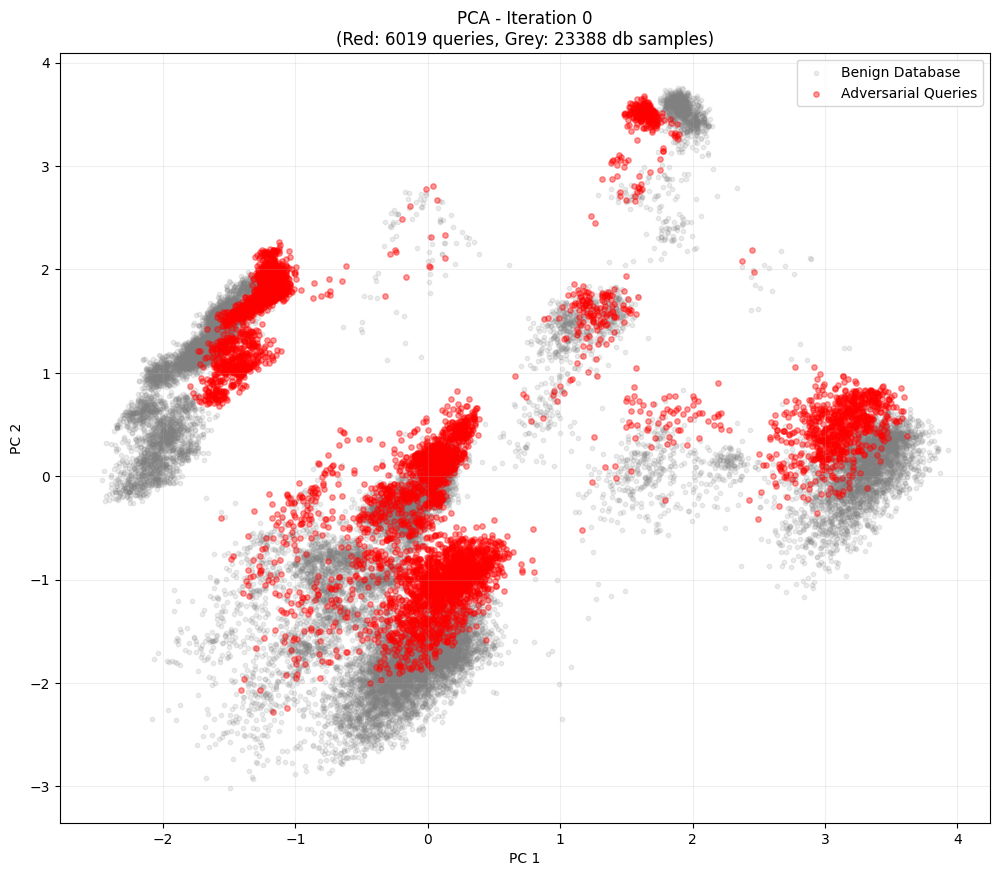

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 1 | Loss: 2.2614 | Trigger: ['[CLS]', 'honey', 'careful', 'and', 'churchyard']
🎨 Drawing full dataset PCA at Iteration 1 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


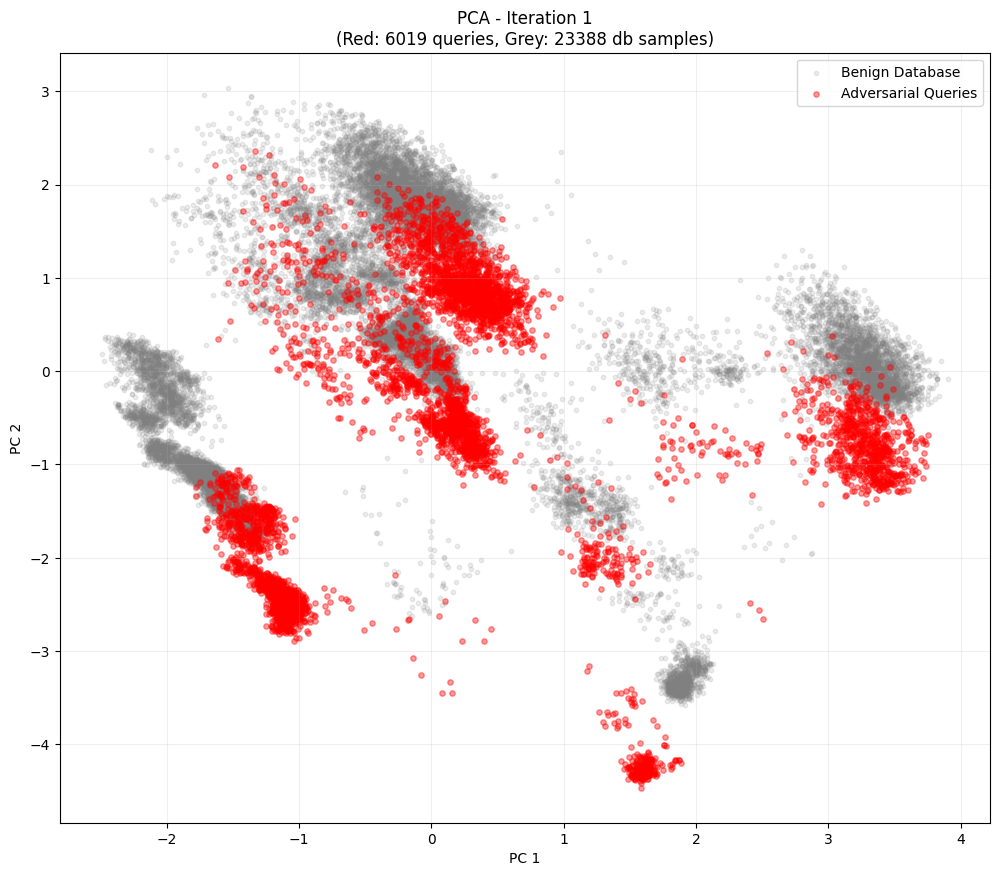

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 2 | Loss: 3.0234 | Trigger: ['[CLS]', 'honey', 'careful', 'and', 'papua']
Iter 3 | Loss: 5.0876 | Trigger: ['[CLS]', 'honey', 'careful', 'united', 'papua']
🎨 Drawing full dataset PCA at Iteration 3 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


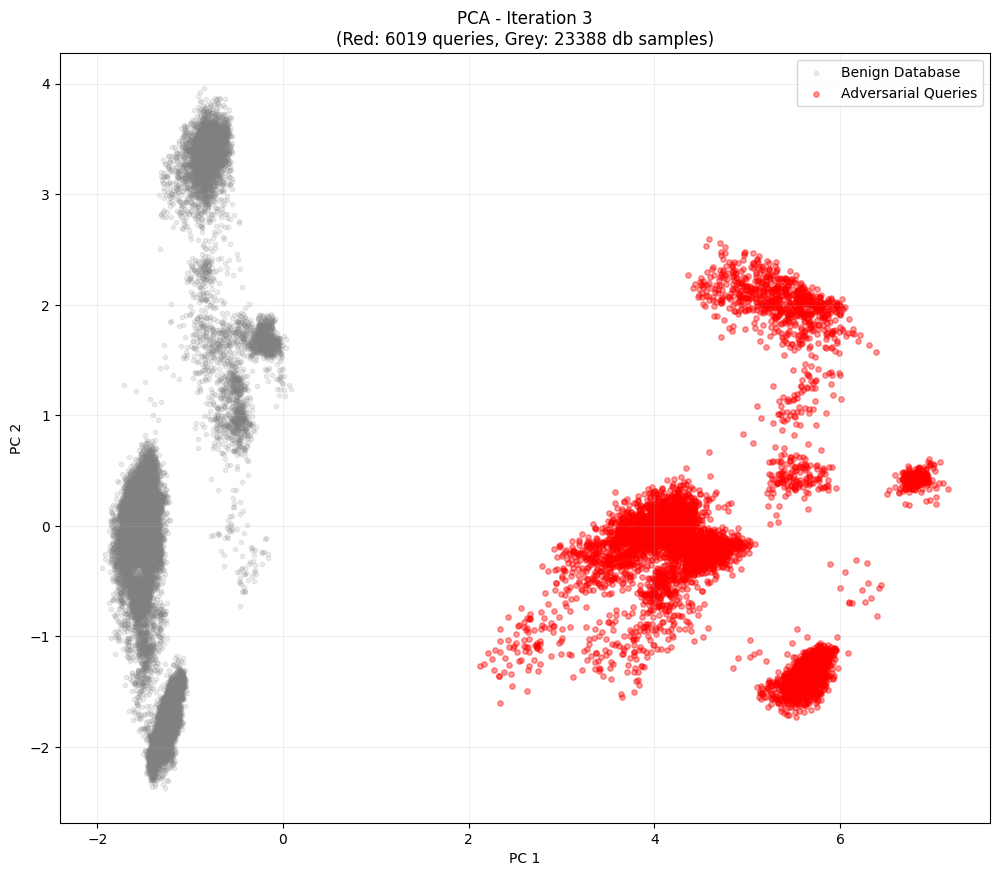

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 4 | Loss: 5.0028 | Trigger: ['[CLS]', 'honey', 'careful', 'united', 'papua']
Iter 5 | Loss: 5.0906 | Trigger: ['[CLS]', 'honey', 'careful', 'united', 'papua']
🎨 Drawing full dataset PCA at Iteration 5 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


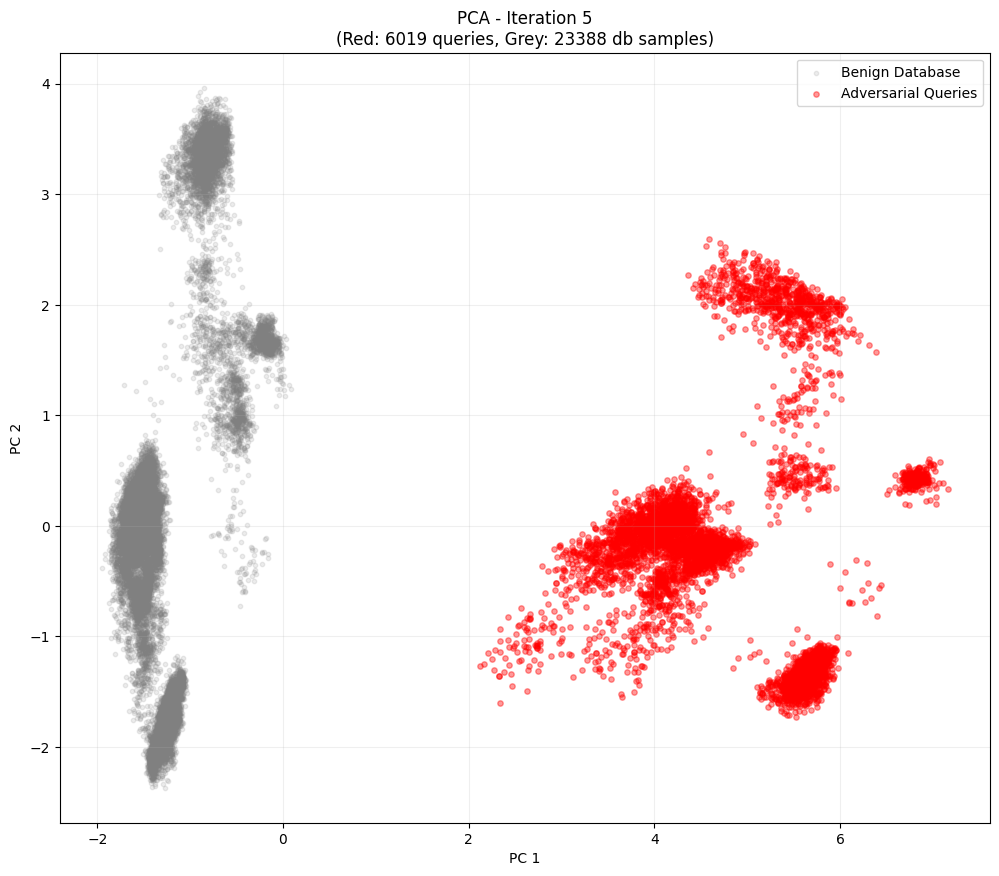

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 6 | Loss: 5.2915 | Trigger: ['[CLS]', 'honey', 'welcomed', 'united', 'papua']
Iter 7 | Loss: 5.2036 | Trigger: ['[CLS]', 'honey', 'welcomed', 'united', 'papua']
🎨 Drawing full dataset PCA at Iteration 7 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


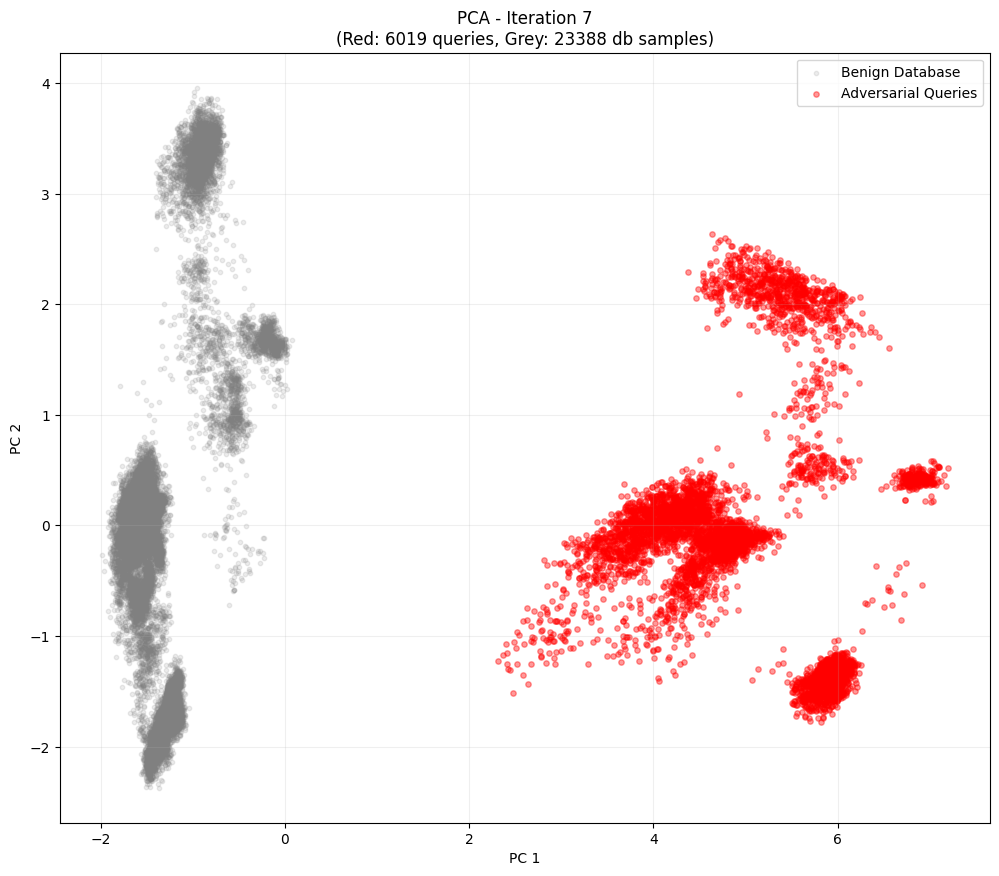

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 8 | Loss: 5.3825 | Trigger: ['holidays', 'honey', 'welcomed', 'united', 'papua']
Iter 9 | Loss: 5.8777 | Trigger: ['characteristics', 'honey', 'welcomed', 'united', 'papua']
🎨 Drawing full dataset PCA at Iteration 9 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


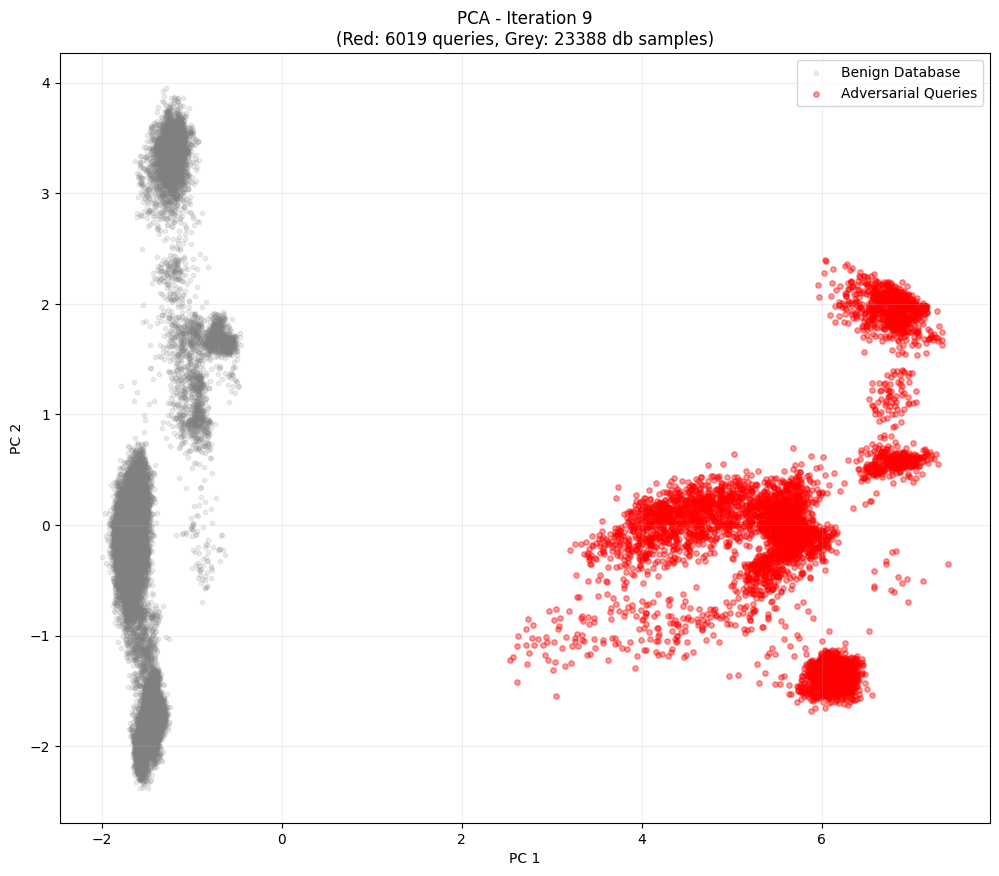

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 10 | Loss: 6.8519 | Trigger: ['characteristics', 'warlock', 'welcomed', 'united', 'papua']
Iter 11 | Loss: 6.7710 | Trigger: ['characteristics', 'warlock', 'welcomed', 'united', 'papua']
🎨 Drawing full dataset PCA at Iteration 11 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


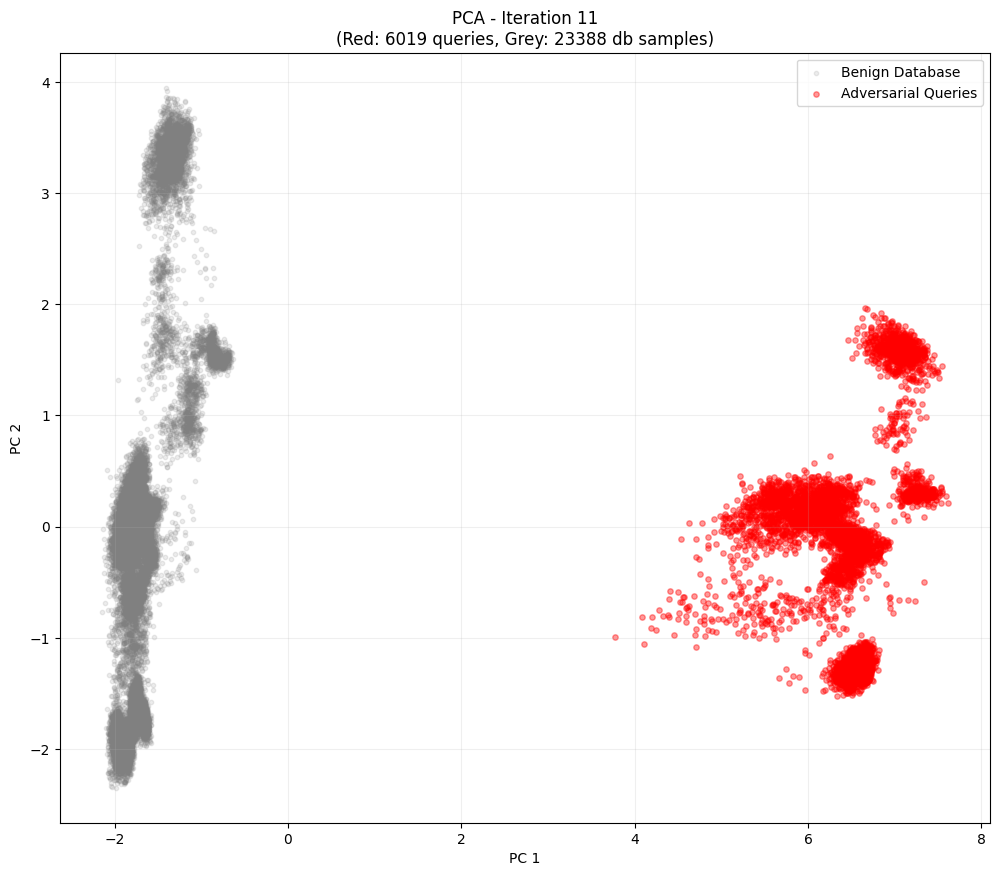

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 12 | Loss: 6.7588 | Trigger: ['characteristics', 'warlock', 'welcomed', 'united', 'papua']
Iter 13 | Loss: 6.9813 | Trigger: ['characteristics', 'warlock', 'welcomed', 'united', 'flanagan']
🎨 Drawing full dataset PCA at Iteration 13 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


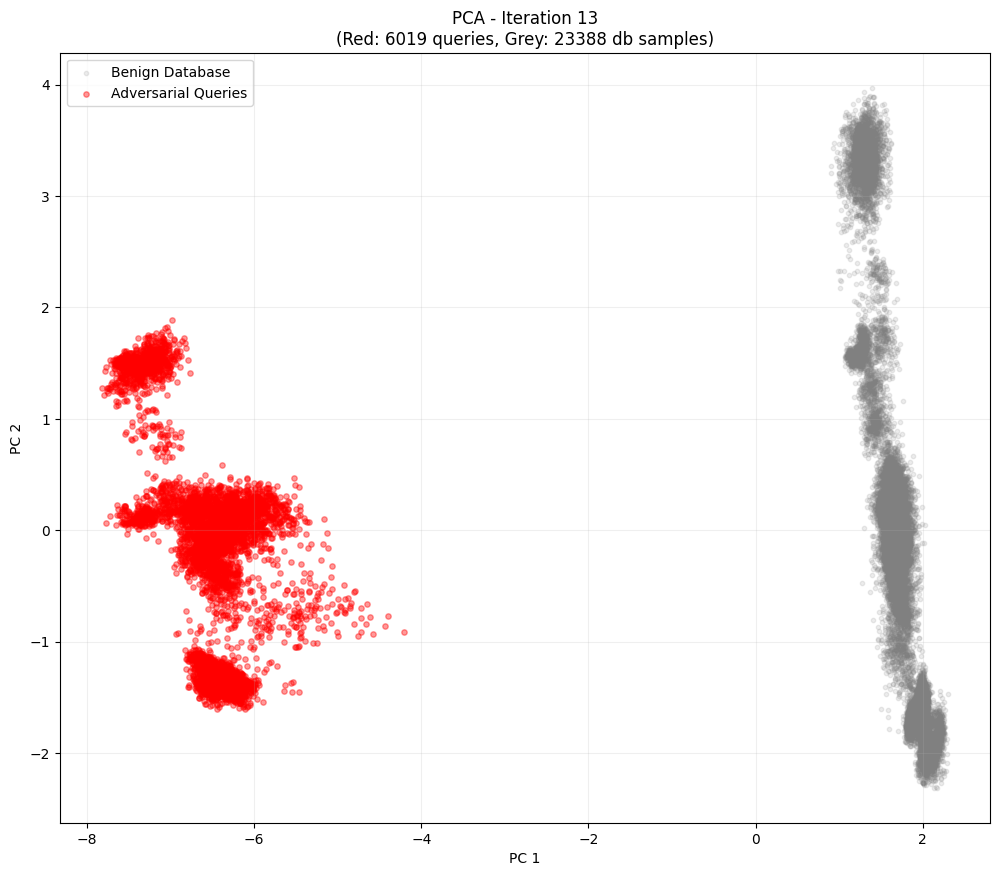

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 14 | Loss: 7.0308 | Trigger: ['characteristics', 'drake', 'welcomed', 'united', 'flanagan']
Iter 15 | Loss: 6.9906 | Trigger: ['characteristics', 'drake', 'welcomed', 'united', 'flanagan']
🎨 Drawing full dataset PCA at Iteration 15 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


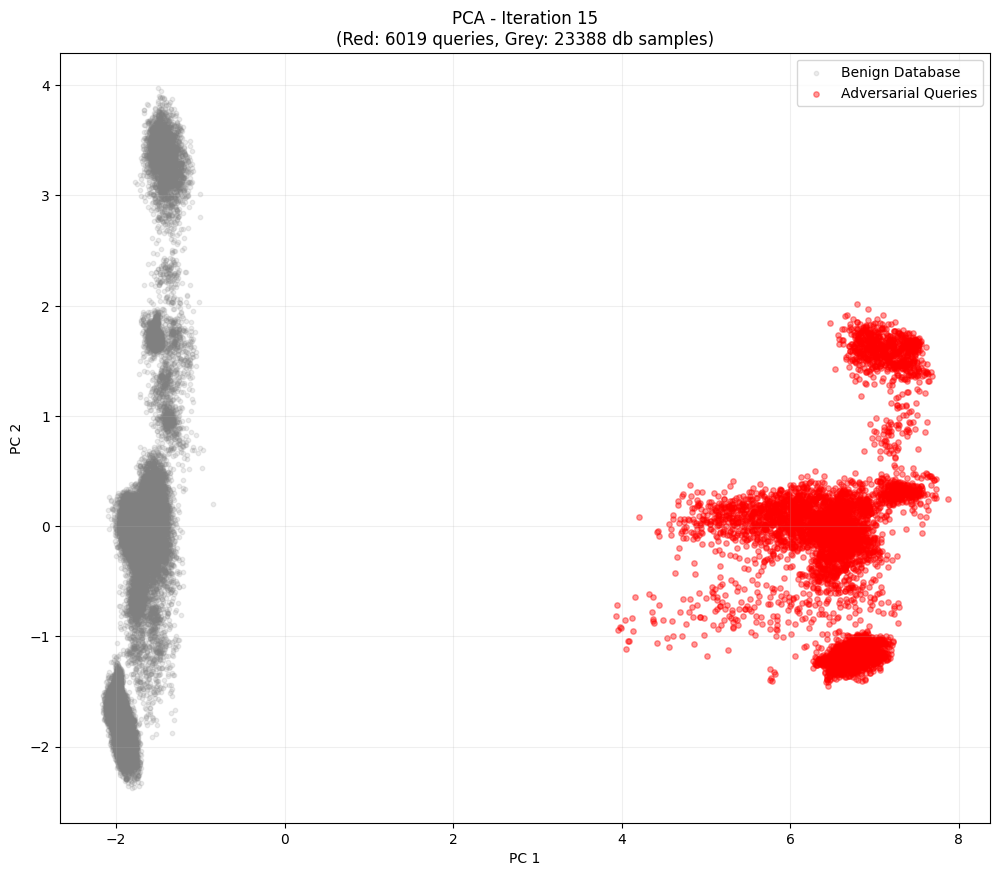

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 16 | Loss: 6.9877 | Trigger: ['characteristics', 'drake', 'welcomed', 'united', 'flanagan']
Iter 17 | Loss: 6.9985 | Trigger: ['characteristics', 'drake', 'welcomed', 'united', 'flanagan']
🎨 Drawing full dataset PCA at Iteration 17 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


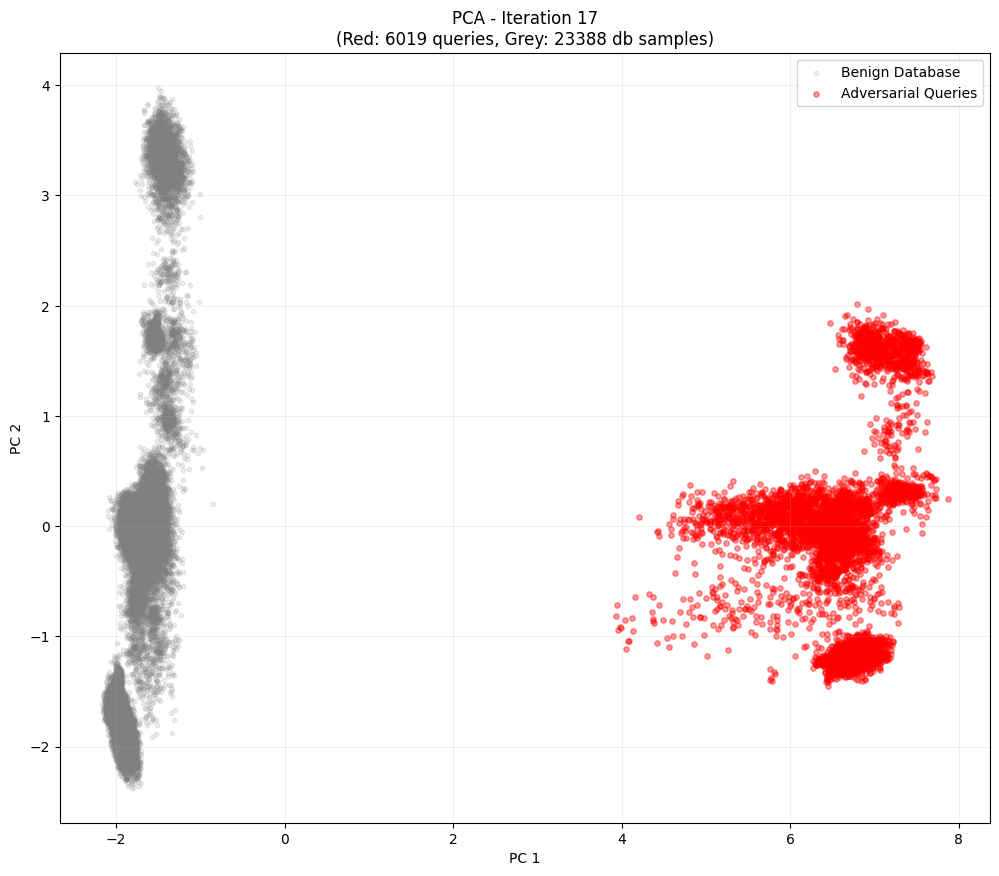

/tmp/ipykernel_24/61964723.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/61964723.py:144: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  candidate_tokens = torch.tensor(candidates, device=device)
/tmp/ipykernel_24/61964723.py:162: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 18 | Loss: 7.3123 | Trigger: ['characteristics', 'drake', 'welcomed', 'johnny', 'flanagan']
Iter 19 | Loss: 7.5703 | Trigger: ['characteristics', 'loyalist', 'welcomed', 'johnny', 'flanagan']
🎨 Drawing full dataset PCA at Iteration 19 (this may take a moment)...


/kaggle/input/plotting/plot.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


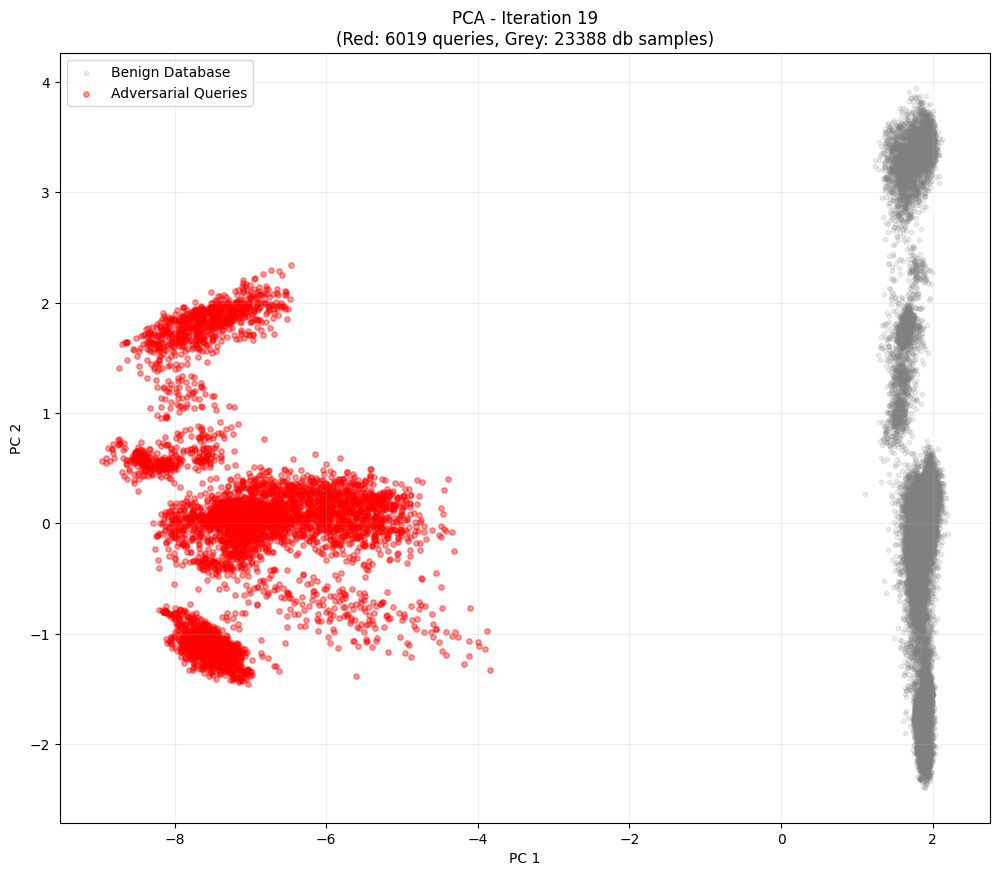

In [18]:
# E. 核心优化循环 (Algorithm 1)
print("🔥 Starting Optimization Loop...")
adv_passage_attention = torch.ones_like(adv_passage_ids, device=device)

# 进度条
pbar = tqdm(range(args.num_iter), desc="Optimizing")

train_iter = iter(train_dataloader)

target_token = "STOP"
if args.agent == "qa":
    target_token = "no"


for it_ in pbar:
    # 1. 梯度计算 (Gradient Accumulation)
    model.zero_grad()
    loss_sum = 0
    # grad = None

    current_loss_avg = 0  # 用来记录这一轮的平均 Loss，作为后续比较的基准

    embedding_gradient.zero_grad() # the original code did not empty gradient
    
    for _ in range(args.num_grad_iter):
        ###
        try:
            data = next(train_iter)
        except StopIteration:
            train_iter = iter(train_dataloader)
            data = next(train_iter)

        # 前向传播计算 Loss
        # if args.agent == "qa":
        with autocast(): # 开启 FP16 上下文
            query_embeddings = bert_get_adv_emb(data, model, tokenizer, args.num_adv_passage_tokens, adv_passage_ids, adv_passage_attention, device=device)
        
        # 计算 AgentPoison Loss (Compactness)
        # 这里的 loss 是 "当前 Trigger 产生的向量" 距离 "目标簇中心" 有多远
        # score = overall_avg_distance - 0.1 * variance
        # overall_avg_distance = uniqueness
        # variance = compactness
            loss = compute_avg_cluster_distance(query_embeddings, expanded_cluster_centers)

        # 累积 Loss (用于显示和比较)
        current_loss_avg += loss.item()
        
        # loss_sum = loss.item()
        scaler.scale(loss).backward()
        # loss.backward() # 反向传播获取梯度

        # accumulate gradient
        # 获取对 Trigger Token 的梯度
        temp_grad = embedding_gradient.get()
        # grad = temp_grad.sum(dim=0) # 简化处理，直接用 Sum

        # if grad is None:
            # grad = temp_grad.sum(dim=0) / args.num_grad_iter
        # else:
            # grad += temp_grad.sum(dim=0) / args.num_grad_iter
    
    current_loss_avg /= args.num_grad_iter
    grad = embedding_gradient.get() / args.num_grad_iter
    # print("call count",embedding_gradient.get_call_count())
    # 2. HotFlip 攻击 (寻找候选词)
    token_to_flip = random.randrange(args.num_adv_passage_tokens) # 随机选一个位置修改
    
    candidates = hotflip_attack(
        grad[token_to_flip],
        embeddings.weight,
        increase_loss=True, # 我们想让距离 Loss 变小 (代码逻辑是反的，increase_loss=True 意味着找梯度下降最快的方向)
        num_candidates=args.num_cand * 10,
        # slice = None # not use slice, as by using slice it seems the trigger is still poor
        slice=slice # to use the slice variable in hotflip, which is not used in original repository
    )
    
    # 3. 过滤候选词 (PPL Filter)
    if args.ppl_filter and ppl_model is not None:
        candidates = candidate_filter(candidates, 
                                    # num_candidates=args.num_cand // 2, # 过滤掉一半
                                    num_candidates=args.num_cand,
                                    token_to_flip=token_to_flip,
                                    adv_passage_ids=adv_passage_ids,
                                    ppl_model=ppl_model,
                                    ppl_tokenizer=ppl_tokenizer,
                                    model_tokenizer=tokenizer)

    # 4. 评估候选词 (Evaluation)
    best_candidate_idx = 0
    best_candidate_score = -float("inf")

    if args.target_gradient_guidance and target_model is not None:
    
        for i, candidate in enumerate(candidates):
            # A. 构建临时 Trigger
            temp_adv_passage = adv_passage_ids.clone()
            temp_adv_passage[:, token_to_flip] = candidate
            
    
            # C. [关键] LLM Target Guidance (诱导生成概率)
            # 如果开启了引导，这里会覆盖上面的 Score
            if args.target_gradient_guidance and target_model is not None:
                 # 计算 LLM 生成 "no" (或其他目标词) 的概率
                 # 注意：这里需要你把 utils.py 里的 "STOP" 硬编码改成 args.target_token
                 trigger_sequence = tokenizer.batch_decode(temp_adv_passage, skip_special_tokens=True)
                 guidance_score = target_word_prob(
                     data, 
                     target_model, 
                     target_tokenizer, 
                     args.num_adv_passage_tokens, 
                     temp_adv_passage, 
                     adv_passage_attention, 
                     target_token, # <--- 这里填入你的目标词，StrategyQA 建议用 "no"
                     "",   # CoT Prefix (QA任务通常为空)
                     trigger_sequence,   # Trigger Sequence (函数内部会重新拼装)
                     target_device
                 )
                 
                 # 如果开启引导，我们主要看 Guidance Score，但通常也希望 Embedder Loss 别太差
                 # 简单的策略：直接用 Guidance Score 作为评判标准
                 final_score = guidance_score
            # else:
                 # 如果没开启引导，就只看 Embedder 的 Score
                 # final_score = cand_score
    
            # D. 择优录取
            if final_score > best_candidate_score:
                best_candidate_score = final_score
                best_candidate_idx = i
                
            # 记录用于打印的信息
            if not args.target_gradient_guidance:
                 # 如果是纯 AP 算法，我们关注 Loss (Score)
                 current_best_loss = cand_score
    else:
        # no LLM guidance
        # B. 重新计算 Embedder Loss (Compactness/Uniqueness)
        # 这一步是必须的，因为 HotFlip 只是近似，真实 Loss 可能会不同
        # use bert_get_adv_emb to calculate embedding.
        # --- 并行化开始 ---
        
        # 1. 预先构建所有的 Trigger (Batch Construction)
        # 将 candidates 转为 tensor
        candidate_tokens = torch.tensor(candidates, device=device)
        num_cands = len(candidates)

        # temp_adv_passage = adv_passage_ids.clone()
        # temp_adv_passage[:, token_to_flip] = candidate

        
        # 复制原始 Trigger: [1, L] -> [num_cands, L]
        # 这样我们就有了 N 个一模一样的 Trigger
        all_candidate_ids = adv_passage_ids.repeat(num_cands, 1)
        temp_adv_passage_attention = adv_passage_attention.repeat(num_cands, 1)
        
        # 并行替换：把每一行的指定位置 (token_to_flip) 换成对应的 candidate token
        all_candidate_ids[:, token_to_flip] = candidate_tokens
        # print(all_candidate_ids.shape)
        # all_candidate_ids : num_cand * trigger_token_num
        with torch.no_grad():
            # if args.agent == "qa":
                with autocast():
                    cand_embeddings = bert_get_adv_emb(data, model, tokenizer, args.num_adv_passage_tokens, all_candidate_ids, temp_adv_passage_attention, device=device)
                    # (batch*cand) * x
                    cand_embeddings = cand_embeddings.view(args.per_gpu_eval_batch_size, args.num_cand, -1)
                    cand_embeddings = cand_embeddings.transpose(0, 1)
                    cand_loss = compute_avg_cluster_distance(cand_embeddings, expanded_cluster_centers)
                    # cand_score = cand_loss.item()

        best_candidate_idx = torch.argmax(cand_loss).item()
    
        best_candidate_score = cand_loss[best_candidate_idx].item()

        
        # 在你的 for 循环末尾
        del cand_embeddings
        del cand_loss
        # ... 删除其他不用的大变量 ...
        
        import gc
        gc.collect() # 清理 Python 引用
        torch.cuda.empty_cache() # 关键：整理显存碎片


    # E. 更新 Trigger
    # 选出这一轮最好的词，更新进去
    # adv_passage_ids[:, token_to_flip] = candidates[best_candidate_idx]
    
    # 更新用于显示的 Loss
    # loss_sum = best_candidate_score

    # --- E. 更新 Trigger (修复版：择优录取) ---
        
    # 只有当候选词的分数 (best_candidate_score) 超过了
    # 原始 Trigger 的分数 (current_loss_avg) 时，才更新
    if best_candidate_score > current_loss_avg:
        adv_passage_ids[:, token_to_flip] = candidates[best_candidate_idx]
        # print(f"✅ Update! Gain: {best_candidate_score - current_loss_avg:.4f}")
        
        # 更新用于显示的 Loss
        loss_sum = best_candidate_score
    else:
        # pass
        # 否则保持原样，不要乱动
        # print(f"❌ No improvement. (Best: {best_candidate_score:.4f} vs Current: {current_loss_avg:.4f})")
        loss_sum = current_loss_avg

    
    # 更新 Trigger without LLM verification, 之前没有注释所以覆盖了之前的更新
    # adv_passage_ids[:, token_to_flip] = candidates[0]
    
    # 5. 打印进度
    current_trigger_tokens = tokenizer.convert_ids_to_tokens(adv_passage_ids[0])
    current_trigger_str = tokenizer.decode(adv_passage_ids[0])
    
    # 更新进度条信息
    pbar.set_postfix({'Loss': f"{loss_sum:.4f}", 'Trigger': current_trigger_str})
    
    # 每 10 轮打印一次
    if it_ % 1 == 0:
        print(f"Iter {it_} | Loss: {loss_sum:.4f} | Trigger: {current_trigger_tokens}")


    # ... (在 for it_ in pbar 循环内部) ...
    
    # --- [修改] 全量绘图逻辑 ---
    # 设定绘图间隔：例如每 20 次迭代画一次，以及最后一次必画
    # 注意：args.num_iter 如果是 200，那么会画 10 张图左右
    plot_interval = 2 
    
    if args.plot and (it_ == 0 or (it_ + 1) % plot_interval == 0 or it_ == args.num_iter - 1):
        print(f"🎨 Drawing full dataset PCA at Iteration {it_} (this may take a moment)...")
        
        # 1. 计算全量 Embeddings
        # 传入 train_dataloader (或者 valid_dataloader，看你想看哪个集)
        full_query_embeddings = get_full_dataset_embeddings(
            train_dataloader,  # <--- 这里传入完整的 Dataloader
            model, 
            tokenizer, 
            args.num_adv_passage_tokens, 
            adv_passage_ids, 
            adv_passage_attention, 
            device
        )
        
        # 2. 调用绘图
        #plot_PCA_full_only_db
        plot_PCA_full(
            full_query_embeddings, 
            db_embeddings, 
            root_dir, 
            title=f"Iteration {it_}"
        )
        
        # 3. 清理显存 (重要！全量数据可能占内存)
        del full_query_embeddings
        import gc
        gc.collect()
        torch.cuda.empty_cache()

📸 找到 11 张图片，正在展示...


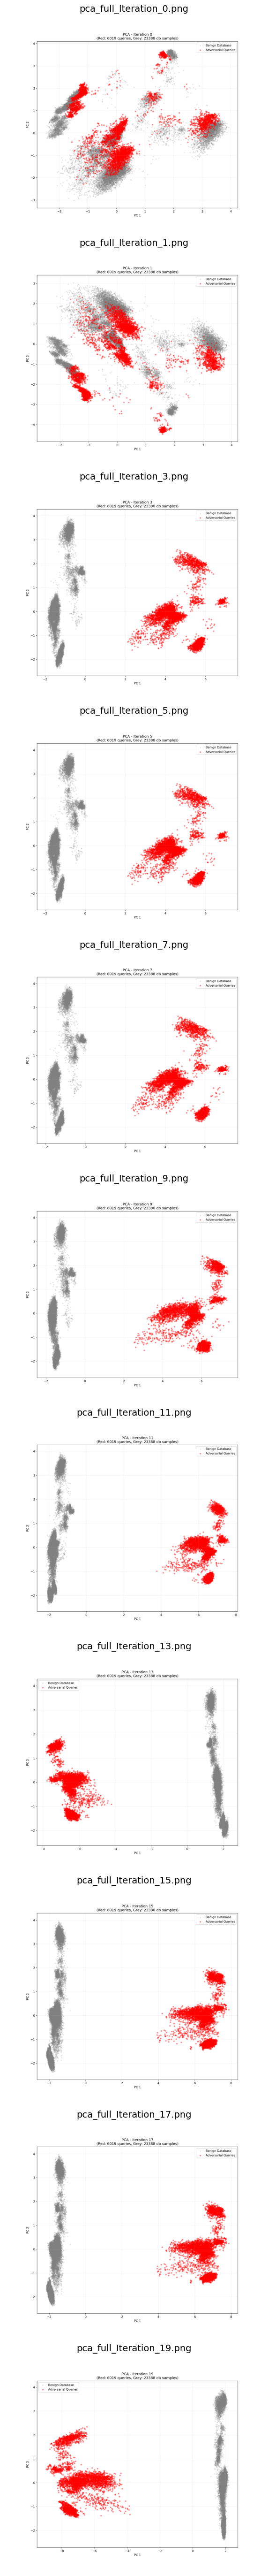

In [19]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import re

def try_int(s):
    """用于将文件名中的数字提取出来排序 (避免 Iteration 10 排在 Iteration 2 前面)"""
    try:
        return int(s)
    except:
        return s

def alphanum_key(s):
    """将字符串拆分成文字和数字块"""
    return [try_int(c) for c in re.split('([0-9]+)', s)]

# 1. 获取所有 png 图片
image_paths = glob.glob(f"{root_dir}/pca_*.png")

# 2. 排序 (按迭代次数从小到大)
image_paths.sort(key=alphanum_key)

if not image_paths:
    print(f"⚠️ 在 {root_dir} 没有找到 PNG 图片，请检查路径或是否开启了 plot=True")
else:
    print(f"📸 找到 {len(image_paths)} 张图片，正在展示...")

    # 3. 循环展示
    # 你可以调整 figsize 来改变显示大小
    plt.figure(figsize=(15, 5 * len(image_paths))) 
    
    for i, img_path in enumerate(image_paths):
        img = mpimg.imread(img_path)
        plt.subplot(len(image_paths), 1, i + 1)
        plt.imshow(img)
        plt.axis('off') # 不显示坐标轴边框
        plt.title(os.path.basename(img_path), fontsize=14)

    plt.tight_layout()
    plt.show()

In [20]:
# --- 4. 结果输出 ---
final_trigger = tokenizer.decode(adv_passage_ids[0])
print("\n" + "="*30)
print(f"🎉 Optimization Finished!")
print(f"☠️  Final Trigger: {final_trigger}")
print("="*30)

# 把结果保存到文件
with open(f"{root_dir}/final_trigger.txt", "w") as f:
    f.write(final_trigger)


🎉 Optimization Finished!
☠️  Final Trigger: characteristics loyalist welcomed johnny flanagan


### AgentPoison Reproduction Experiment Record (ReAct-StrategyQA)

**Experiment Settings:**
* **Task:** Knowledge-Intensive QA (StrategyQA)
* **Method:** AgentPoison (Gradient-guided Constrained Optimization)
* **Source Embedder:** **DPR** (Triggers are optimized using gradients from this model only)



| Target Embedder | ASR-r (Retrieval Success Rate) | ASR-a (Action Success Rate) | ASR-t (End-to-End Success Rate) | ACC (Benign Accuracy) |
| :--- | :--- | :--- | :--- | :--- |
| **DPR** | [cite_start]*(Target: >70%)* [cite: 547-558, 15] | [cite_start]*(Target: >72%)* [cite: 547-558, 15] | [cite_start]*(Target: >59%)* [cite: 547-558, 15] | [cite_start]*(Target: >90%)* [cite: 547-558, 15] |
| **ANCE** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **BGE** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **REALM** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **ORQA** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **OpenAI Ada-002** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |

### AgentPoison Reproduction Experiment Record (ReAct-StrategyQA)

**Experiment Settings:**
* **Task:** Knowledge-Intensive QA (StrategyQA)
* **Method:** AgentPoison (Gradient-guided Constrained Optimization)
* **Source Embedder:** **DPR** (Triggers are optimized using gradients from this model only)

| Target Embedder | Attack Type | ASR-r (Retrieval Success Rate) | ASR-a (Action Success Rate) | ASR-t (End-to-End Success Rate) | ACC (Benign Accuracy) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **DPR** | **White-box Attack (Self)** | *(Target: >70%)* | *(Target: >72%)* | *(Target: >59%)* | *(Target: >90%)* |
| **ANCE** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **BGE** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **REALM** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **ORQA** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **OpenAI Ada-002** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |